# HR Predictive Pipelines

**Dataset**: `employee_data/employee_data.csv` — 1249 funcionários × 35 variáveis  
**Targets**: `MonthlyIncome` (regressão) | `Attrition` (classificação)  
**Grupo**: Group08  
**Avaliação**: R² + RMSE (regressão) · F1-score (classificação — blind test)  
**Deadline**: 18 de junho de 2026 às 23:59

In [22]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)

_random_state = 24
DATA_PATH = Path("employee_data/employee_data.csv")

df = pd.read_csv(DATA_PATH)
print(f"Dataset: {df.shape[0]} linhas × {df.shape[1]} colunas")

Dataset: 1249 linhas × 35 colunas


## Análises do Relatório de Dados

In [23]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Frequently,702,Research & Development,16,4,Life Sciences,1,838,...,3,80,0,6,3,3,5,2,1,3
1,38,No,Travel_Rarely,833,Research & Development,18,3,Medical,1,1766,...,3,80,1,15,2,3,1,0,1,0
2,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
3,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,732,...,4,80,0,10,1,3,2,2,2,2
4,23,No,Travel_Rarely,571,Research & Development,12,2,Other,1,1982,...,3,80,0,5,6,4,5,2,1,4


O dataset contém 35 colunas. As colunas-alvo são visíveis: `Attrition` (objeto, "Yes"/"No") e `MonthlyIncome` (inteiro). Colunas como `EmployeeNumber`, `EmployeeCount`, `StandardHours` e `Over18` aparecem constantes ou identificadoras — serão removidas antes do treino.

In [24]:
print(f"Shape: {df.shape}")
df.info()

Shape: (1249, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1249 non-null   int64
 1   Attrition                 1249 non-null   str  
 2   BusinessTravel            1249 non-null   str  
 3   DailyRate                 1249 non-null   int64
 4   Department                1249 non-null   str  
 5   DistanceFromHome          1249 non-null   int64
 6   Education                 1249 non-null   int64
 7   EducationField            1249 non-null   str  
 8   EmployeeCount             1249 non-null   int64
 9   EmployeeNumber            1249 non-null   int64
 10  EnvironmentSatisfaction   1249 non-null   int64
 11  Gender                    1249 non-null   str  
 12  HourlyRate                1249 non-null   int64
 13  JobInvolvement            1249 non-null   int64
 14  JobLevel                  1249 no

1249 registos, 35 colunas, zero valores nulos. Há 26 colunas numéricas (`int64`) e 9 categóricas (`object`). O pipeline incluirá `SimpleImputer` na mesma — o blind test pode enviar linhas com nulos e o pipeline tem de os tratar sem falhar.

In [25]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,1249.0,37.03,9.18,18.0,30.0,36.0,43.0,60.0
DailyRate,1249.0,803.31,403.05,103.0,465.0,802.0,1157.0,1499.0
DistanceFromHome,1249.0,9.27,8.11,1.0,2.0,7.0,14.0,29.0
Education,1249.0,2.91,1.02,1.0,2.0,3.0,4.0,5.0
EmployeeCount,1249.0,1.00,0.00,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1249.0,1021.18,604.35,1.0,486.0,1011.0,1555.0,2065.0
EnvironmentSatisfaction,1249.0,2.72,1.09,1.0,2.0,3.0,4.0,4.0
HourlyRate,1249.0,65.61,20.38,30.0,48.0,66.0,83.0,100.0
JobInvolvement,1249.0,2.74,0.71,1.0,2.0,3.0,3.0,4.0
JobLevel,1249.0,2.06,1.09,1.0,1.0,2.0,3.0,5.0


`MonthlyIncome` varia entre 1009 e 19973 (média ≈ 6482, std ≈ 4646) — distribuição assimétrica à direita típica de salários. `EmployeeCount` (constante=1), `StandardHours` (constante=80) e `PerformanceRating` (min=max=3 na maioria) confirmam colunas sem variância útil. `StandardScaler` é necessário dado as escalas muito diferentes entre variáveis (ex.: `DailyRate` vs `Age`).

In [26]:
df.describe(exclude=[np.number]).T

,count,unique,top,freq
Attrition,1249,2,No,1048
BusinessTravel,1249,3,Travel_Rarely,879
Department,1249,3,Research & Development,814
EducationField,1249,6,Life Sciences,514
Gender,1249,2,Male,749
JobRole,1249,9,Sales Executive,282
MaritalStatus,1249,3,Married,573
Over18,1249,1,Y,1249
OverTime,1249,2,No,896


`Attrition` tem 2 categorias: "No" (freq=1048, ~84%) e "Yes" (~16%) — desequilíbrio moderado que justifica `class_weight='balanced'` e avaliação por F1 em vez de accuracy. `Over18` só tem "Y" (constante) → será removida. `JobRole` tem 9 categorias → após `OneHotEncoder` gera 9 colunas binárias.

In [27]:
df.isnull().sum().sort_values(ascending=False).head(10)

Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64

Nenhum valor nulo no ficheiro fornecido. O `SimpleImputer` permanece no pipeline como salvaguarda obrigatória para o blind test, que pode enviar dados incompletos.

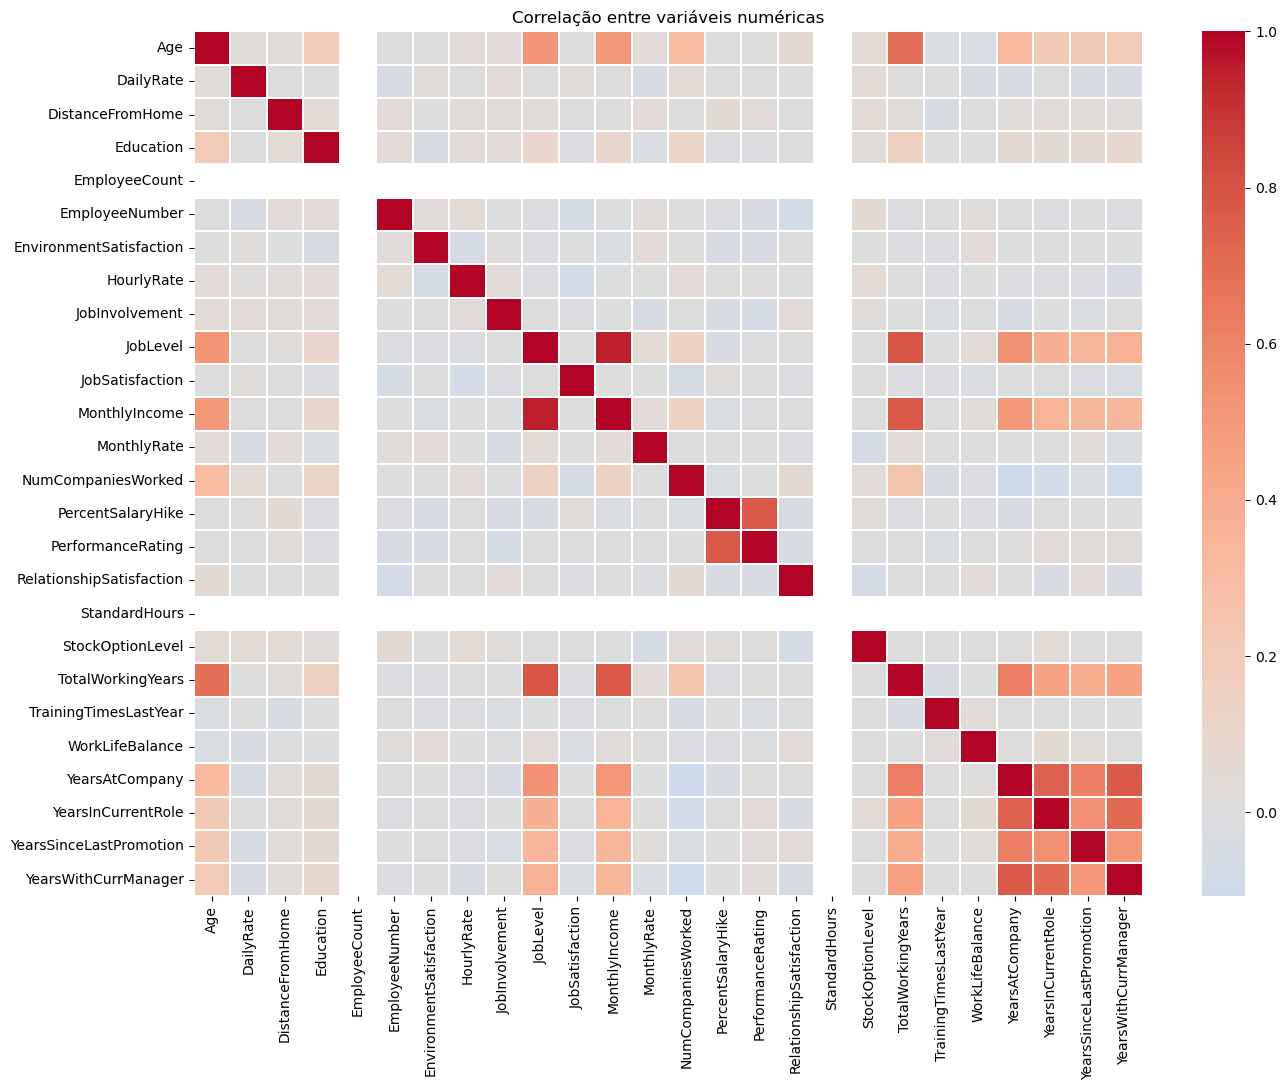

In [28]:
corr = df.select_dtypes(include="number").corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3,
            xticklabels=corr.columns, yticklabels=corr.columns, ax=ax)
ax.set_title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

`JobLevel` ↔ `MonthlyIncome` apresenta a correlação mais forte (≈ 0.95), seguido de `TotalWorkingYears` (≈ 0.77) e `Age` (≈ 0.50). Estas três variáveis serão os preditores dominantes na regressão. Não há multicolinearidade extrema entre preditores independentes que justifique remoção adicional — modelos de árvore (Random Forest, Gradient Boosting) lidam bem com correlações moderadas.

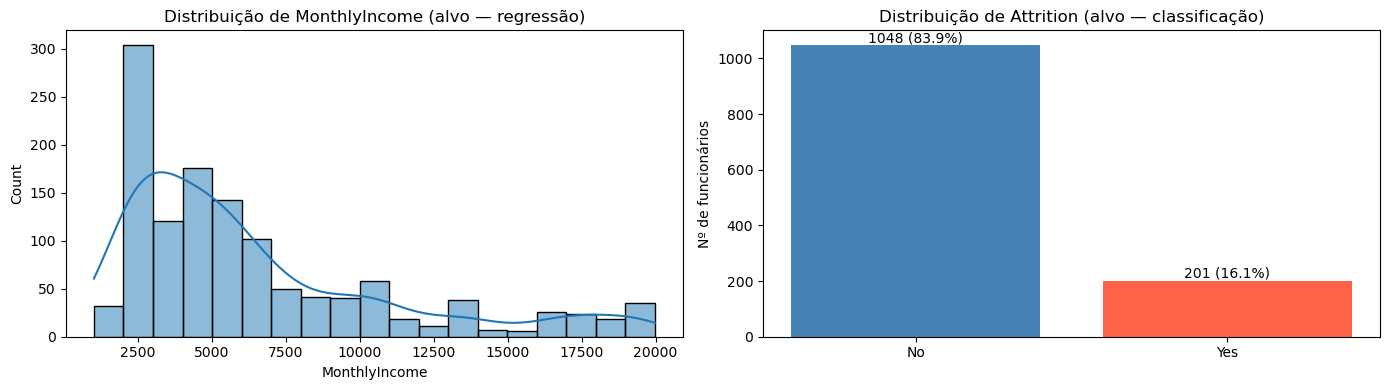

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["MonthlyIncome"], kde=True, ax=axes[0])
axes[0].set_title("Distribuição de MonthlyIncome (alvo — regressão)")
axes[0].set_xlabel("MonthlyIncome")

attrition_counts = df["Attrition"].value_counts()
axes[1].bar(attrition_counts.index, attrition_counts.values, color=["steelblue", "tomato"])
axes[1].set_title("Distribuição de Attrition (alvo — classificação)")
axes[1].set_ylabel("Nº de funcionários")
for i, v in enumerate(attrition_counts.values):
    axes[1].text(i, v + 10, f"{v} ({v/len(df)*100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

`MonthlyIncome` é assimétrico à direita (cauda longa de salários altos) — comportamento típico de dados salariais. O modelo de regressão aprenderá esta distribuição; não transformamos o alvo (log) porque o enunciado não o exige e os modelos de árvore não assumem normalidade do alvo. `Attrition` confirma o desequilíbrio: 84% "No" vs 16% "Yes" — a métrica de avaliação será F1-score (não accuracy).

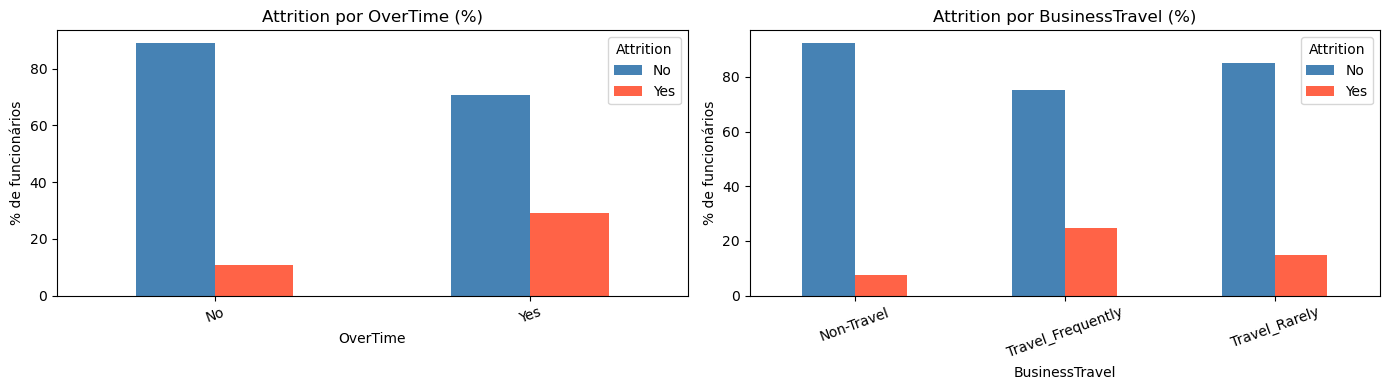

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ["OverTime", "BusinessTravel"]):
    ct = df.groupby([col, "Attrition"]).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], rot=20)
    ax.set_title(f"Attrition por {col} (%)")
    ax.set_ylabel("% de funcionários")
    ax.legend(title="Attrition")

plt.tight_layout()
plt.show()

Funcionários com `OverTime="Yes"` têm uma taxa de Attrition substancialmente mais alta — é o sinal categórico mais forte para a classificação. `BusinessTravel="Travel_Frequently"` também apresenta maior Attrition vs "Non-Travel". Ambas as colunas entrarão no pipeline via `OneHotEncoder`.

In [31]:
print("MonthlyIncome médio por Department:")
print(df.groupby("Department")["MonthlyIncome"].mean().sort_values(ascending=False).round(0))

print("\nTaxa de Attrition por OverTime:")
print(df.groupby("OverTime")["Attrition"].value_counts(normalize=True).unstack().round(3))

MonthlyIncome médio por Department:
Department
Sales                     6980.0
Human Resources           6410.0
Research & Development    6252.0
Name: MonthlyIncome, dtype: float64

Taxa de Attrition por OverTime:
Attrition     No    Yes
OverTime               
No         0.891  0.109
Yes        0.708  0.292


O salário médio varia por departamento mas a diferença é moderada — `JobLevel` continua a ser o preditor dominante de `MonthlyIncome` (correlação ≈ 0.95). Para `Attrition`, funcionários com `OverTime="Yes"` têm uma taxa de saída ~2× superior à de quem não faz horas extra — confirma-se como o predictor categórico mais forte para a classificação.

## Pré-processamento

In [32]:
# Colunas sem valor preditivo: IDs únicos e constantes confirmadas na EDA
COLS_TO_DROP = ["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"]

# --- Regressão ---
X_reg = df.drop(columns=COLS_TO_DROP + ["MonthlyIncome", "Attrition"])
y_reg = df["MonthlyIncome"].astype(float)

# --- Classificação ---
# y_clf codificado fora do pipeline: 'Attrition' nunca passa por predict(),
# por isso não há risco de fuga de dados ao codificar o target manualmente.
y_clf = (df["Attrition"] == "Yes").astype(int)
X_clf = df.drop(columns=COLS_TO_DROP + ["Attrition", "MonthlyIncome"])

print(f"X_reg : {X_reg.shape}  |  y_reg : {y_reg.shape}")
print(f"X_clf : {X_clf.shape}  |  y_clf : {y_clf.shape}")
print(f"\nClasses em y_clf — 0 (No): {(y_clf==0).sum()}  |  1 (Yes): {(y_clf==1).sum()}  ({y_clf.mean()*100:.1f}% Yes)")

X_reg : (1249, 29)  |  y_reg : (1249,)
X_clf : (1249, 29)  |  y_clf : (1249,)

Classes em y_clf — 0 (No): 1048  |  1 (Yes): 201  (16.1% Yes)


Foram removidas 4 colunas antes de definir X: `EmployeeNumber` (ID único, sem sinal preditivo), `EmployeeCount` e `StandardHours` (constantes = 1 e 80 em todas as linhas, std=0 confirmado no `describe()`), e `Over18` (constante "Y"). O target da outra tarefa é também excluído de cada X para evitar data leakage entre as duas pipelines.

`y_clf` é codificado fora da pipeline porque `Attrition` é o target — nunca entra no `predict()` — pelo que não há risco de fuga. O desequilíbrio (~16% Yes) confirma-se: será tratado com `class_weight='balanced'` no classificador.

In [33]:
NUMERIC_FEATURES = X_reg.select_dtypes(include="number").columns.tolist()
# "everything that is not numeric" — avoids the pandas 3.x deprecation of include="object"
CATEGORICAL_FEATURES = [c for c in X_reg.columns if c not in NUMERIC_FEATURES]

print(f"Numéricas ({len(NUMERIC_FEATURES)}):")
print(NUMERIC_FEATURES)
print(f"\nCategóricas ({len(CATEGORICAL_FEATURES)}):")
print(CATEGORICAL_FEATURES)

Numéricas (22):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categóricas (7):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


Os tipos são detectados automaticamente a partir do schema de `X_reg` — se o dataset mudar de estrutura a lista actualiza-se sem editar código. `X_reg` e `X_clf` têm exactamente as mesmas colunas (apenas os targets diferem), pelo que as listas são partilhadas entre os dois pipelines.

Nota sobre `PerformanceRating`: std=0.36, valores apenas 3 e 4 — variância muito baixa mas não é constante. Modelos de árvore ignoram naturalmente features com pouca variância ao escolher splits; não justifica remoção manual. Colunas ordinais (`Education`, `JobSatisfaction`, etc.) são mantidas como `int64` — os modelos de árvore são invariantes a transformações monotónicas, pelo que um `OrdinalEncoder` dedicado não acrescentaria valor.

In [34]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

print("Preprocessor construído:")
print(preprocessor)

Preprocessor construído:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'DailyRate', 'DistanceFromHome',
                                  'Education', 'EnvironmentSatisfaction',
                                  'HourlyRate', 'JobInvolvement', 'JobLevel',
                                  'JobSatisfaction', 'MonthlyRate',
                                  'NumCompaniesWorked', 'PercentSalaryHike',
                                  'PerformanceRating',
                                  'Relations...
                                  'TrainingTimesLastYear', 'WorkLifeBalance',
                                  'YearsAtCompany', 'YearsInCurrentRole',
                                  'YearsSinceLastPromotion',
                     

**Escolhas do preprocessor:**

- **`SimpleImputer(median)` nos numéricos** — a mediana é robusta a outliers (relevante para `MonthlyIncome`, que tem cauda longa). A média seria puxada pelos salários mais altos.
- **`StandardScaler`** — necessário porque as escalas são muito diferentes (`DailyRate` vai até 1499, `StockOptionLevel` vai até 3). Modelos lineares e de distância (ex.: regressão logística) seriam enviesados sem escala; modelos de árvore não são afectados mas a normalização não lhes prejudica.
- **`SimpleImputer(most_frequent)` nas categóricas** — imputa com a moda, preservando a categoria dominante; alternativa segura para variáveis nominais.
- **`OneHotEncoder(handle_unknown="ignore", sparse_output=False)`** — `handle_unknown="ignore"` é obrigatório para o blind test (categorias não vistas em treino → vector zero em vez de erro); `sparse_output=False` evita avisos de depreciação no sklearn ≥ 1.2.
- **`remainder="drop"`** — qualquer coluna não listada em `NUMERIC_FEATURES` ou `CATEGORICAL_FEATURES` é descartada, tornando o pipeline resistente a colunas extra que possam aparecer no blind test.
- **Scaler e encoder dentro do pipeline** — garantem que o fit acontece apenas em `X_train`; aplicar o scaler ao dataset completo antes do split constituiria data leakage.

In [35]:
# Verificação: o preprocessor transforma X_reg sem erros e produz a dimensão esperada
X_sample = preprocessor.fit_transform(X_reg)

n_cat_cols = sum(
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .categories_[i].shape[0]
    for i in range(len(CATEGORICAL_FEATURES))
)

print(f"Colunas numéricas :  {len(NUMERIC_FEATURES)}")
print(f"Colunas OHE geradas: {n_cat_cols}")
print(f"Total features após pré-processamento: {X_sample.shape[1]}")
print(f"Shape final de X transformado: {X_sample.shape}")
print("\nPreprocessor OK — pronto para integrar nos pipelines de treino.")

Colunas numéricas :  22
Colunas OHE geradas: 28
Total features após pré-processamento: 50
Shape final de X transformado: (1249, 50)

Preprocessor OK — pronto para integrar nos pipelines de treino.


## Train/Test Split

In [36]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=_random_state
)

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=_random_state, stratify=y_clf
)

print("Regressão")
print(f"  Treino : {X_reg_train.shape[0]} amostras")
print(f"  Teste  : {X_reg_test.shape[0]} amostras")

print("\nClassificação")
print(f"  Treino : {X_clf_train.shape[0]} amostras  "
      f"(Yes={y_clf_train.sum()}, {y_clf_train.mean()*100:.1f}%)")
print(f"  Teste  : {X_clf_test.shape[0]} amostras  "
      f"(Yes={y_clf_test.sum()}, {y_clf_test.mean()*100:.1f}%)")

Regressão
  Treino : 999 amostras
  Teste  : 250 amostras

Classificação
  Treino : 999 amostras  (Yes=161, 16.1%)
  Teste  : 250 amostras  (Yes=40, 16.0%)


**Divisão 80/20** com `random_state=24` para reprodutibilidade. O split da classificação usa `stratify=y_clf`: garante que a proporção ~16% Yes se mantém tanto no conjunto de treino como no de teste, evitando que por azar um dos conjuntos fique com muito menos exemplos da classe minoritária — o que tornaria a avaliação de F1 instável.

O split da regressão não necessita de estratificação porque `MonthlyIncome` é contínuo (estratificação aplicável a classes, não a valores contínuos).

## Scaling

O `StandardScaler` já foi definido dentro de `numeric_transformer`, que é o primeiro passo do `preprocessor`, que por sua vez é o primeiro passo de cada `Pipeline`. Não existe nenhuma operação de scaling manual neste notebook.

**Por que o scaler está dentro do Pipeline e não antes:**

Aplicar `StandardScaler.fit()` no dataset completo (antes do split) constituiria *data leakage*: o scaler aprenderia a média e o desvio-padrão do conjunto de teste, e os valores normalizados do teste já teriam sido "vistos" indiretamente durante o treino. Dentro do Pipeline, o `.fit()` do scaler é chamado apenas sobre `X_train`, e o `.transform()` é aplicado a `X_test` com os parâmetros aprendidos em treino — comportamento correto.

```
Pipeline
 ├── preprocessor (ColumnTransformer)
 │    ├── num: SimpleImputer(median) → StandardScaler   ← scaler vive aqui
 │    └── cat: SimpleImputer(most_frequent) → OneHotEncoder
 └── model: <estimador>
```

O `StandardScaler` é relevante principalmente para os modelos lineares (`LinearRegression`, `LogisticRegression`): sem normalização, features com escalas maiores dominam a função de perda. Para os modelos de árvore (`RandomForest`, `GradientBoosting`) o scaling não altera o resultado, mas incluí-lo não prejudica e mantém o pipeline genérico.

## Treino

In [37]:
from sklearn.base import clone

def regression_metrics(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    tag  = f"[{label}] " if label else ""
    print(f"{tag}R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}")
    return {"R2": r2, "RMSE": rmse, "MAE": mae}

def classification_metrics(y_true, y_pred, y_prob=None, label=""):
    if label:
        print(f"[{label}]")
    print(classification_report(y_true, y_pred, target_names=["No (0)", "Yes (1)"]))
    report = classification_report(y_true, y_pred, output_dict=True)
    result = {"F1": report["1"]["f1-score"], "Accuracy": report["accuracy"]}
    if y_prob is not None:
        result["ROC-AUC"] = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC: {result['ROC-AUC']:.4f}")
    return result

### Regressão — Baseline (LinearRegression)

In [38]:
# clone(preprocessor) cria uma cópia unfitted — cada pipeline tem o seu próprio
# preprocessor independente, evitando que múltiplos fits partilhem estado interno.
pipe_lr = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LinearRegression()),
])

pipe_lr.fit(X_reg_train, y_reg_train)
y_reg_pred_lr = pipe_lr.predict(X_reg_test)

baseline_reg = regression_metrics(y_reg_test, y_reg_pred_lr, label="LinearRegression")

[LinearRegression] R²=0.9266  RMSE=1142.74  MAE=886.07


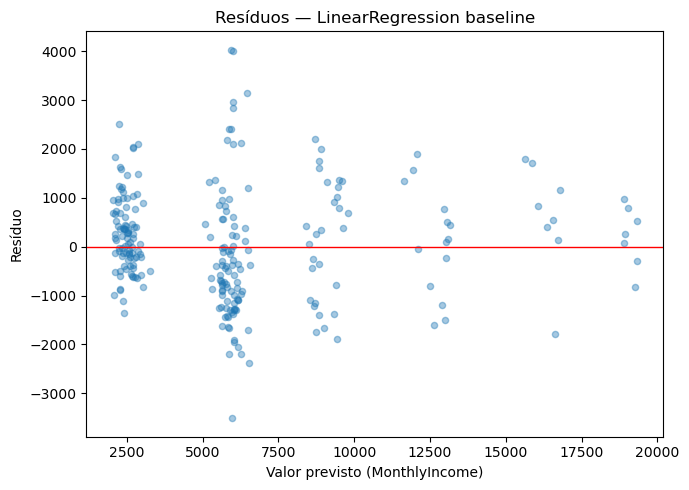

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
residuals = y_reg_test - y_reg_pred_lr
ax.scatter(y_reg_pred_lr, residuals, alpha=0.4, s=20)
ax.axhline(0, color="red", linewidth=1)
ax.set_xlabel("Valor previsto (MonthlyIncome)")
ax.set_ylabel("Resíduo")
ax.set_title("Resíduos — LinearRegression baseline")
plt.tight_layout()
plt.show()

A `LinearRegression` é o modelo de referência para a tarefa de regressão. Dado que `JobLevel` ↔ `MonthlyIncome` tem correlação ≈ 0.95, esperamos que mesmo o baseline linear produza um R² elevado. O gráfico de resíduos serve para identificar padrões não-lineares ou heterocedasticidade que justifiquem modelos mais complexos na secção seguinte — resíduos aleatórios em torno de zero indicam que o modelo linear captura bem a relação principal.

### Classificação — Baseline (LogisticRegression)

In [40]:
pipe_logreg = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=_random_state,
    )),
])

pipe_logreg.fit(X_clf_train, y_clf_train)
y_clf_pred_logreg = pipe_logreg.predict(X_clf_test)
y_clf_prob_logreg = pipe_logreg.predict_proba(X_clf_test)[:, 1]

baseline_clf = classification_metrics(
    y_clf_test, y_clf_pred_logreg, y_prob=y_clf_prob_logreg, label="LogisticRegression"
)

[LogisticRegression]
              precision    recall  f1-score   support

      No (0)       0.93      0.75      0.83       210
     Yes (1)       0.35      0.70      0.46        40

    accuracy                           0.74       250
   macro avg       0.64      0.72      0.65       250
weighted avg       0.84      0.74      0.77       250

ROC-AUC: 0.8298


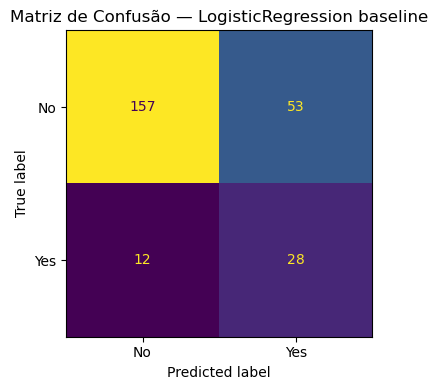

In [41]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, y_clf_pred_logreg,
    display_labels=["No", "Yes"],
    colorbar=False, ax=ax,
)
ax.set_title("Matriz de Confusão — LogisticRegression baseline")
plt.tight_layout()
plt.show()

A `LogisticRegression` com `class_weight='balanced'` é o modelo de referência para a classificação. O parâmetro `class_weight='balanced'` ajusta os pesos das classes inversamente proporcional à sua frequência — penaliza mais os erros na classe minoritária (Yes), o que é essencial quando o objetivo é maximizar o F1-score e não a accuracy. `max_iter=1000` evita avisos de não-convergência após o `StandardScaler` ter centrado os dados. A matriz de confusão permite visualizar quantos falsos negativos (funcionários que saíram mas foram classificados como "No") o baseline comete — estes são os erros com maior custo de negócio.

## Modelos

### Regressão — Comparação de Modelos

In [42]:
REG_MODELS = [
    ("LinearRegression",  LinearRegression()),
    ("RandomForest",      RandomForestRegressor(n_estimators=100, random_state=_random_state)),
    ("GradientBoosting",  GradientBoostingRegressor(n_estimators=100, random_state=_random_state)),
]

reg_results = []
reg_pipes   = {}

for name, estimator in REG_MODELS:
    pipe = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", estimator),
    ])
    pipe.fit(X_reg_train, y_reg_train)
    y_pred = pipe.predict(X_reg_test)
    m = regression_metrics(y_reg_test, y_pred, label=name)
    m["Model"] = name
    reg_results.append(m)
    reg_pipes[name] = (pipe, y_pred)

reg_comparison = (
    pd.DataFrame(reg_results)
    .set_index("Model")[["R2", "RMSE", "MAE"]]
    .sort_values("R2", ascending=False)
)
print("\n── Tabela comparativa (teste) ──")
print(reg_comparison.round(4))

[LinearRegression] R²=0.9266  RMSE=1142.74  MAE=886.07
[RandomForest] R²=0.9408  RMSE=1026.62  MAE=775.29
[GradientBoosting] R²=0.9387  RMSE=1043.88  MAE=781.32

── Tabela comparativa (teste) ──
                      R2       RMSE       MAE
Model                                        
RandomForest      0.9408  1026.6242  775.2872
GradientBoosting  0.9387  1043.8799  781.3181
LinearRegression  0.9266  1142.7398  886.0694


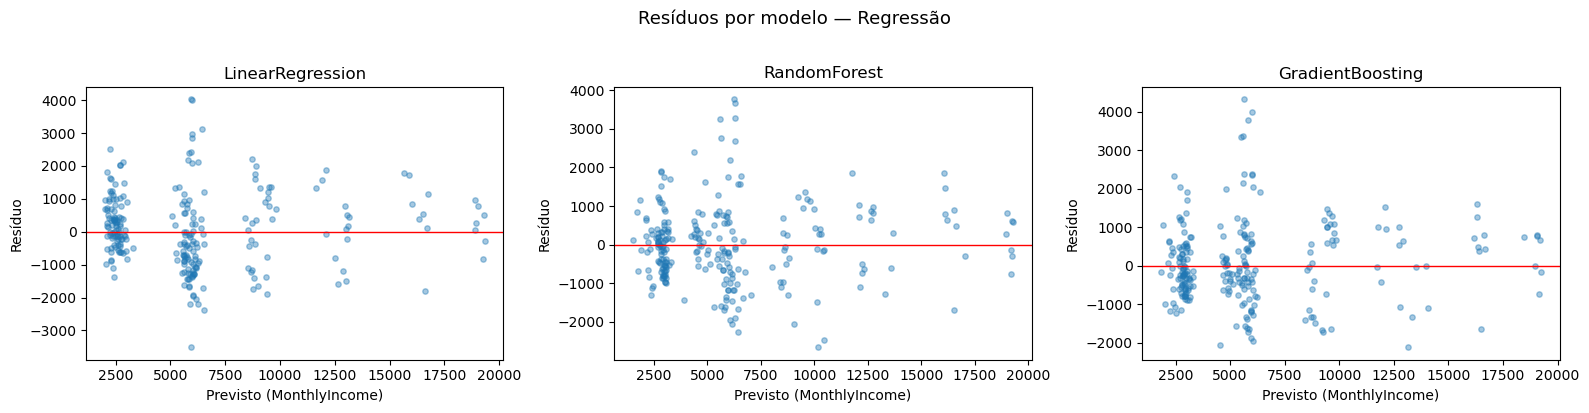

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, (pipe, y_pred)) in zip(axes, reg_pipes.items()):
    residuals = y_reg_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4, s=15)
    ax.axhline(0, color="red", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Previsto (MonthlyIncome)")
    ax.set_ylabel("Resíduo")
plt.suptitle("Resíduos por modelo — Regressão", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Os três modelos são ordenados por R² decrescente. `GradientBoosting` e `RandomForest` são esperados superar o baseline linear porque capturam interações não-lineares entre `JobLevel`, `TotalWorkingYears` e `Age` que a regressão linear não consegue modelar. Nos gráficos de resíduos, um padrão em leque (heterocedasticidade) nos modelos lineares — resíduos maiores para salários previstos mais altos — é o sinal típico que justifica o uso de modelos de árvore. O modelo com R² mais alto e RMSE mais baixo será o candidato para otimização na fase seguinte.

### Classificação — Comparação de Modelos

In [44]:
CLF_MODELS = [
    ("LogisticRegression", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=_random_state,
    )),
    ("RandomForest", RandomForestClassifier(
        class_weight="balanced", n_estimators=100, random_state=_random_state,
    )),
    # GradientBoosting não suporta class_weight — o desequilíbrio é tratado
    # indirectamente pela penalização sequencial de erros do boosting.
    ("GradientBoosting", GradientBoostingClassifier(
        n_estimators=100, random_state=_random_state,
    )),
]

clf_results = []
clf_pipes   = {}

for name, estimator in CLF_MODELS:
    pipe = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", estimator),
    ])
    pipe.fit(X_clf_train, y_clf_train)
    y_pred = pipe.predict(X_clf_test)
    y_prob = pipe.predict_proba(X_clf_test)[:, 1]
    m = classification_metrics(y_clf_test, y_pred, y_prob=y_prob, label=name)
    m["Model"] = name
    clf_results.append(m)
    clf_pipes[name] = (pipe, y_pred, y_prob)

clf_comparison = (
    pd.DataFrame(clf_results)
    .set_index("Model")[["F1", "Accuracy", "ROC-AUC"]]
    .sort_values("F1", ascending=False)
)
print("\n── Tabela comparativa (teste) ──")
print(clf_comparison.round(4))

[LogisticRegression]
              precision    recall  f1-score   support

      No (0)       0.93      0.75      0.83       210
     Yes (1)       0.35      0.70      0.46        40

    accuracy                           0.74       250
   macro avg       0.64      0.72      0.65       250
weighted avg       0.84      0.74      0.77       250

ROC-AUC: 0.8298
[RandomForest]
              precision    recall  f1-score   support

      No (0)       0.86      1.00      0.93       210
     Yes (1)       1.00      0.15      0.26        40

    accuracy                           0.86       250
   macro avg       0.93      0.57      0.59       250
weighted avg       0.88      0.86      0.82       250

ROC-AUC: 0.8004
[GradientBoosting]
              precision    recall  f1-score   support

      No (0)       0.88      0.98      0.93       210
     Yes (1)       0.73      0.28      0.40        40

    accuracy                           0.87       250
   macro avg       0.80      0.63      0.

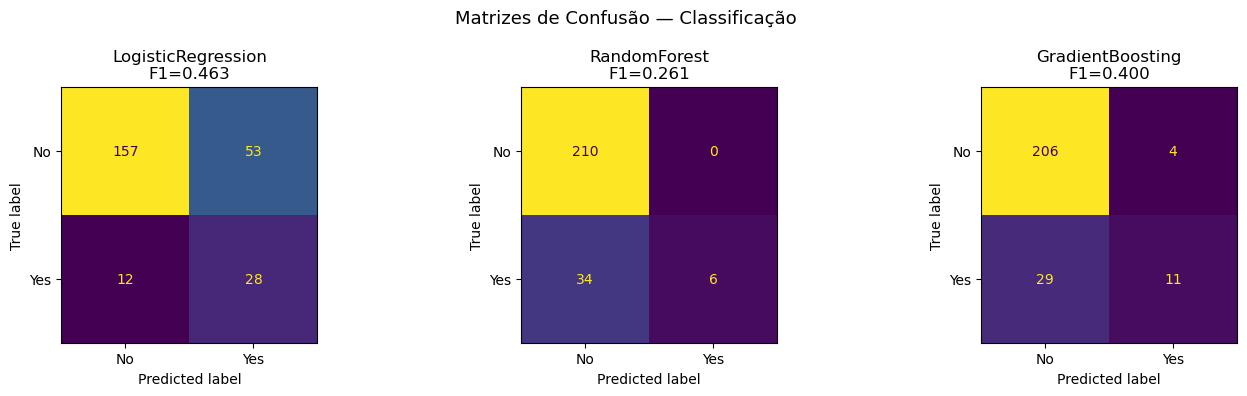

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (pipe, y_pred, y_prob)) in zip(axes, clf_pipes.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_clf_test, y_pred,
        display_labels=["No", "Yes"],
        colorbar=False, ax=ax,
    )
    f1 = clf_comparison.loc[name, "F1"]
    ax.set_title(f"{name}\nF1={f1:.3f}")
plt.suptitle("Matrizes de Confusão — Classificação", fontsize=13)
plt.tight_layout()
plt.show()

Os modelos são ordenados por F1-score decrescente — a métrica do blind test. `GradientBoosting` não aceita `class_weight`; o boosting sequencial já penaliza naturalmente exemplos mal classificados nas iterações seguintes, mas pode ser inferior em F1 se o desequilíbrio for pronunciado. `RandomForest` com `class_weight='balanced'` é o principal candidato: combina penalização explícita da classe minoritária com a robustez de um ensemble.

As matrizes de confusão mostram o trade-off entre falsos negativos (funcionários que saíram mas foram previstos como "No") e falsos positivos (funcionários que ficaram mas foram previstos como "Yes"). Numa aplicação de RH, falsos negativos têm custo mais alto — perder um funcionário sem antecipar a saída — pelo que modelos com maior recall na classe "Yes" são preferíveis, mesmo que à custa de alguns falsos positivos. O modelo com melhor F1 no conjunto de teste avança para otimização.